
# Web Scraping -- Beautifulsoup

---

###  Scraping Basics
---

Web scraping is a technique of extracting information from websites. It focuses on transformation of unstructured data on the web, into structured data that can be stored and analyzed.



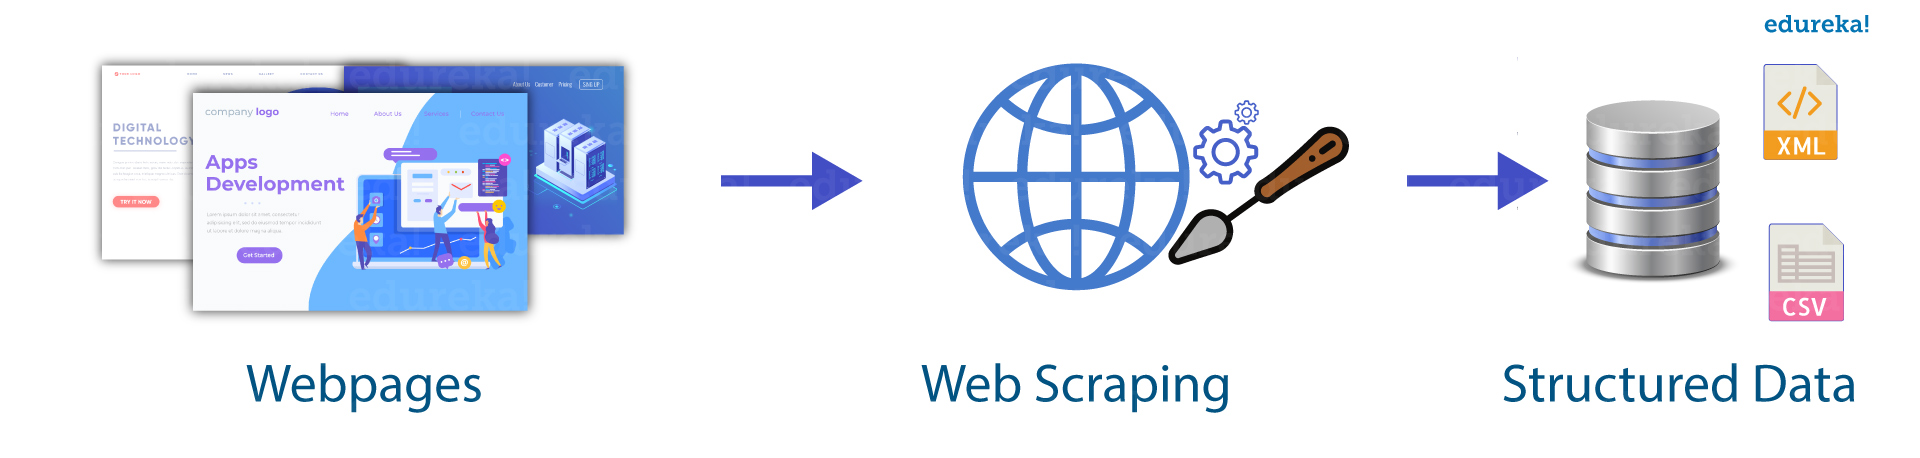



## Why do we scrape the web?

* Realistically, data that you want to study won't always be available to you in the form of a curated data set.
* Need to go to the internets to find interesting data:
    * From an existing company
    * Text for NLP
    * Images


## 👉 Ethical Scraping Guidelines:

- __Terms of Use :__ Respect the _Terms of Use_ & _robots.txt_
- __Minimize Burden :__ Minimizing burden on website owners. Introduce a time delay (>1 second) between scrapes, and scrape at times of day when web traffic is likely to be low.
- __Personal Information :__ Don't scrape personal information.
- __Notify :__ Notify the website owners where possible. They may just send you the data 😁

For more information on how to read __robots.txt__ 👉 https://www.seerinteractive.com/insights/how-to-read-robots-txt

In this notebook we will learn how to scrape websites responsibly using BeautifulSoup. For more information, please check out the BeautifulSoup Documentation page : https://beautiful-soup-4.readthedocs.io/en/latest/

# Scraping from a Web Page with Python

Scraping a web site basically comes down to making a **request from Python and parsing through the HTML** that is returned from each page. For each of these tasks we have a Python library, **`requests` and `bs4`**, respectively.



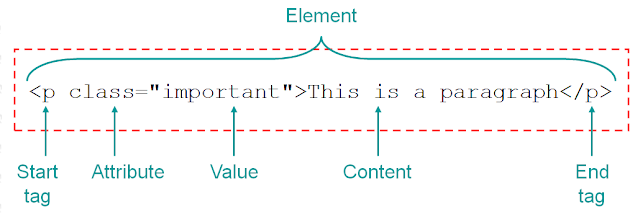

## Element Parent / Child Relationships

<img src="http://web.simmons.edu/~grabiner/comm244/weekfour/tree.gif" width="500">

**Elements begin and end in the same namespace like so:**  `<p></p>`

**Elements can have parents and children:**

```html
<body>
    <div>I am inside the parent element
        <div>I am inside a child element</div>
        <div>I am inside another child element</div>
        <div>I am inside yet another child element</div>
    </div>
</body>
```

## Element Attributes

Elements can also have attributes!  Attributes are defined inside **element tags** and can contain data that may be useful to scrape.

```html
<a href="https://weather.com/?Goto=Redirected" title="A title" id="web-link" name="hal">A Simple Link</a>
```

The **element attributes** of this `<a>` tag element are:
- href
- title
- id
- name




This `<a>` tag example will render in your browser like this:

> <a href="https://weather.com/?Goto=Redirected">A Simple Link</a>

### Getting Info from a Web Page

Now that we can gain easy access to the HMTL for a web page, we need **some way to pull the desired content from it**. Luckily there is already a system in place to do this. With a **combination of HMTL and CSS selectors** we can identify the information on a HMTL page that we wish to retrieve and grab it with [BeautifulSoup](https://www.crummy.com/software/BeautifulSoup/bs4/doc/#searching-the-tree).

### Let us have an example

In [1]:
myhtml = '''
<!DOCTYPE html>
<html>

<head>
    <title>The title of this web page</title>
</head>

<body>
    <h1>My Photos</h1>
    <div class="intro">
        <p>These are some photos of my trips.</p>
        <img src="me.png" />
    </div>
    <h3>Italy</h3>
    <div class="country" id="venice">
        <img alt="Venice" src="venice1.png" /> <br />
        <img alt="Venice" src="venice2.png" /> <br />
        <img alt="Roma" src="rome.png" />
    </div>
    <h3>Germany</h3>
    <div class="country" id="berlin">
        <img alt="Berlin" src="berlin.png" />
    </div>
    <h3>Denmark</h3>
    <div class="country">
        <img alt="Copenhagen" src="Copenhagen.png" />
    </div>
</body>

</html>
'''

In [2]:
from bs4 import BeautifulSoup

# we create a soup object with the html:
soup = BeautifulSoup(myhtml, 'html.parser')

In [3]:
soup # here is our soup object!


<!DOCTYPE html>

<html>
<head>
<title>The title of this web page</title>
</head>
<body>
<h1>My Photos</h1>
<div class="intro">
<p>These are some photos of my trips.</p>
<img src="me.png"/>
</div>
<h3>Italy</h3>
<div class="country" id="venice">
<img alt="Venice" src="venice1.png"/> <br/>
<img alt="Venice" src="venice2.png"/> <br/>
<img alt="Roma" src="rome.png"/>
</div>
<h3>Germany</h3>
<div class="country" id="berlin">
<img alt="Berlin" src="berlin.png"/>
</div>
<h3>Denmark</h3>
<div class="country">
<img alt="Copenhagen" src="Copenhagen.png"/>
</div>
</body>
</html>

- You can use an online html viewer to display in a nice format 
https://html.onlineviewer.net/

In [4]:
# Find the element of the web page title using .
soup.title

<title>The title of this web page</title>

In [7]:
# Find the text of the title of the whole web page
soup.title.text


'The title of this web page'

In [9]:
# Find the element of the tag h1 using .

soup.h1

<h1>My Photos</h1>

In [10]:
# Find the text of the element of the tag h1 using .
soup.h1.text


'My Photos'

In [11]:
# Find the element of the tag h3 using .
soup.h3


<h3>Italy</h3>

In [12]:
# Find the text of the element of the tag h3 using .
soup.h3.text


'Italy'

## Method `find`:

- BeautifulSoup's `.find()` method is a powerful tool for finding the first element in a HTML or XML page that matches your query criteria.

- You should use the `.find()` method when there is only one element that matches your query criteria, or you just want the first element.
- 
The `.find()` returns the first element that matches your query criteria.

In [13]:
# Find the element of the web page title using .find()
soup.find("title")

<title>The title of this web page</title>

In [15]:
# Find the text of the title of the whole web page using .find()
soup.find("title").text

'The title of this web page'

In [16]:
# Find the element of the tag h3 using find()
soup.find("h3")


<h3>Italy</h3>

In [17]:
# Find the text of the element of the tag h3 using .find()
soup.find("h3").text


'Italy'

In [18]:
# find the element that has a tag called 'div'
soup.find("div")


<div class="intro">
<p>These are some photos of my trips.</p>
<img src="me.png"/>
</div>

In [19]:
# find the element that has 'div' tag and id attribute is 'venice'

soup.find("div", id="venice")


<div class="country" id="venice">
<img alt="Venice" src="venice1.png"/> <br/>
<img alt="Venice" src="venice2.png"/> <br/>
<img alt="Roma" src="rome.png"/>
</div>

In [23]:
# find the element that has 'div' tag and class attribute is 'country'

soup.find("div", class_="country")


<div class="country" id="venice">
<img alt="Venice" src="venice1.png"/> <br/>
<img alt="Venice" src="venice2.png"/> <br/>
<img alt="Roma" src="rome.png"/>
</div>

In [24]:
# find the element with 'div' tag and attribute 'class' as 'country' with 'id' is 'berlin'

soup.find("div", class_="country", id ="berlin")


<div class="country" id="berlin">
<img alt="Berlin" src="berlin.png"/>
</div>

In [26]:
# find the element with 'div' tag and attribute 'class' as 'country' with 'id' is 'berlin'
# same as above but use `attrs=`

soup.find("div", attrs={"class":"country","id": "berlin"})


<div class="country" id="berlin">
<img alt="Berlin" src="berlin.png"/>
</div>

In [33]:
# find the element with 'div' tag and attribute 'class' as 'country' with 'id' is 'venice'
# then find the first element with 'img' tag

soup.find("div", class_="country", id="venice").find("img")




<img alt="Venice" src="venice1.png"/>

In [36]:
# find the element with 'div' tag and attribute 'class' as 'country' with 'id' is 'venice'
# then find the first element with 'img' tag
# then find the value of the tag 'alt'
soup.find("div", class_="country", id="venice").find("img")["alt"]




'Venice'

- How about searching if a specific attribute label exist or not? See below

In [40]:
# find the element that has a 'div' tag and has an attribute called "id"

soup.find("div",id =True)

<div class="country" id="venice">
<img alt="Venice" src="venice1.png"/> <br/>
<img alt="Venice" src="venice2.png"/> <br/>
<img alt="Roma" src="rome.png"/>
</div>

## Method `find_all`:

- The .find_all() method allows you to find all the elements on the page by class name, id, or any other element attribute using the attrs parameter that matches your query criteria.
- The only difference is that find_all() returns a list of all the results, and find() just returns the first result.



In [44]:
# Find all the elements of the tag h3 using find_all()

soup.find_all("h3")

[<h3>Italy</h3>, <h3>Germany</h3>, <h3>Denmark</h3>]

In [49]:
# Find all the elements of the tag h3 using find_all()
# show the text of the first element

soup.find_all("h3")[0].text



'Italy'

In [50]:
# Find all the elements of the tag h3 using find_all()
# show the text of the second element 
soup.find_all("h3")[1].text



'Germany'

In [52]:
# find all the elements that has 'div' tag and class attribute is 'country'

soup.find_all("div", class_ = "country")

[<div class="country" id="venice">
 <img alt="Venice" src="venice1.png"/> <br/>
 <img alt="Venice" src="venice2.png"/> <br/>
 <img alt="Roma" src="rome.png"/>
 </div>,
 <div class="country" id="berlin">
 <img alt="Berlin" src="berlin.png"/>
 </div>,
 <div class="country">
 <img alt="Copenhagen" src="Copenhagen.png"/>
 </div>]

In [54]:
# find all the elements that has 'div' tag and class attribute is 'country'
# Then, show the second element only
soup.find_all("div", class_ = "country")[1]


<div class="country" id="berlin">
<img alt="Berlin" src="berlin.png"/>
</div>

In [55]:
# find all the elements that has 'div' tag and class attribute is 'country' and id is 'venice'
soup.find_all("div", class_ = "country", id = "venice")


[<div class="country" id="venice">
 <img alt="Venice" src="venice1.png"/> <br/>
 <img alt="Venice" src="venice2.png"/> <br/>
 <img alt="Roma" src="rome.png"/>
 </div>]

In [59]:
# find all the elements that has 'div' tag and class attribute is 'country' and id is 'venice'
# select the first element (notice that the list has only one element)
soup.find_all("div", class_ = "country", id = "venice")[0]



<div class="country" id="venice">
<img alt="Venice" src="venice1.png"/> <br/>
<img alt="Venice" src="venice2.png"/> <br/>
<img alt="Roma" src="rome.png"/>
</div>

In [27]:
# find all the elements that has 'div' tag and class attribute is 'country' and id is 'venice'
# Then, find the first element
# Then, find all the elements with tag 'img'
soup.find_all("div", class_ = "country", id = "venice").find(



In [71]:
# find all the elements with tag 'img' and attribute alt is 'Venice'
# notice that the tag name is case sensetive!
soup.findall("img", id ="venice")


TypeError: 'NoneType' object is not callable

### Methods siblings
#### What is Siblings:
> Sibling elements are elements that share the same parent

In [66]:
# Find the element of the tag h3 using .find()
soup.find("h3")


<h3>Italy</h3>

In [67]:
# Find the element of the tag h3 using .find()
# then find all its next 'h3' sibling 
soup.find("h3").find_next_sibling("h3")


<h3>Germany</h3>

In [62]:
# Show the next sibling of 'h3' that has a tag name div

soup.find("h3").find_next_sibling("div")

<div class="country" id="venice">
<img alt="Venice" src="venice1.png"/> <br/>
<img alt="Venice" src="venice2.png"/> <br/>
<img alt="Roma" src="rome.png"/>
</div>

In [61]:
# Show all next siblings for 'h3' tag that have a tag name div
# Notice the difference between "sibling" and "siblings"
soup.find("h3").find_next_siblings("div")


[<div class="country" id="venice">
 <img alt="Venice" src="venice1.png"/> <br/>
 <img alt="Venice" src="venice2.png"/> <br/>
 <img alt="Roma" src="rome.png"/>
 </div>,
 <div class="country" id="berlin">
 <img alt="Berlin" src="berlin.png"/>
 </div>,
 <div class="country">
 <img alt="Copenhagen" src="Copenhagen.png"/>
 </div>]

In [64]:
# find the element that has 'div' tag and class attribute is 'country' 
# Then, find the next 'h3' siblings
soup.find("div", class_="country").find_next_siblings("h3")

[<h3>Germany</h3>, <h3>Denmark</h3>]

In [65]:
# find the element of tag 'div' and class attribute as 'country'
# then find its 'h3' previous siblings using .find_previous_siblings
soup.find("div", class_="country").find_previous_siblings("h3")




[<h3>Italy</h3>]

# Let's try using some webpage!
## Getting Info from a Web Page

### Requests Library

* The `requests`(http://docs.python-requests.org/en/latest/index.html) is designed to simplify the process of making **http requests within Python**. 
* The interface is extremely simple. 
    * Instantiate a requests object to the request, this will mostly be a `get`, with the URL and optional parameters you'd like passed through the request. 
    * That instance make the results of the request available via attributes/methods.
    
It's SUPER EASY!

<a id='response-types'></a>
### Response types overview

> Check these out when you have time -- at least be aware that there is an expected pattern to these codes:

**[Status codes](http://en.wikipedia.org/wiki/List_of_HTTP_status_codes)** have standard meanings; here are a few.

|Code|Reason|
|:---|:-----|
|200| OK
|301| Moved Permanently
|302| Moved Temporarily
|307| Temporary Redirect
|400| Bad Request
|403| Forbidden
|404| Not Found
|500| Internal Server Error

## In-Class Guided Exercise:

Now we’ll use our web scraping and data cleaning skills to scrape prices of books from a bookstore’s website. We’ll be using 

> <a href="https://books.toscrape.com/catalogue/page-2.html">books toscrape site</a>




### First, Import needed libraries for web scraping
- you need to install `requests` or `httpx` before you can import for the first time.
    - both requests and httpx libraries do the same but httpx is a recent one with more features


In [68]:
# you need to install requests or httpx before you can import for the first time.

!pip install requests
!pip install httpx

In [73]:
import requests
import httpx  # if you want to use httpx instead of requests

import pandas as pd
from bs4 import BeautifulSoup
from time import sleep


### Steps on using BeautifulSoup:
#### 1. Specify the link of the page then use `requests.get()` to access the web page you want to scrape

In [124]:
# specify the link you want to scrape
url='https://books.toscrape.com/catalogue/page-2.html'



In [125]:
# use requests.get() to access the web page. save the web page into a variable html_page or call it any name

html_page = requests.get(url)


In [126]:
# check the status code if it is 200 then everthing is OK .status_code

html_page.status_code
# 200 mean OK 

200

In [127]:
# Show the first 500 characters in the html_page

html_page.text[0:500]


'\n\n<!DOCTYPE html>\n<!--[if lt IE 7]>      <html lang="en-us" class="no-js lt-ie9 lt-ie8 lt-ie7"> <![endif]-->\n<!--[if IE 7]>         <html lang="en-us" class="no-js lt-ie9 lt-ie8"> <![endif]-->\n<!--[if IE 8]>         <html lang="en-us" class="no-js lt-ie9"> <![endif]-->\n<!--[if gt IE 8]><!--> <html lang="en-us" class="no-js"> <!--<![endif]-->\n    <head>\n        <title>\n    All products | Books to Scrape - Sandbox\n</title>\n\n        <meta http-equiv="content-type" content="text/html; charset=UTF-8"'

#### 2.Now that we have the web page, we can parse it with beautifulsoup:

In [128]:
soup2 = BeautifulSoup(html_page.text, 'html.parser') #<shift + tab> 

- Get the title of the page using the tag 'title':

In [129]:
soup2.title

<title>
    All products | Books to Scrape - Sandbox
</title>

#### 3. Get all the items in that page
- Use `inspect` on the web page to know how to collect the items 
- Create a variable that contains all the items in that web page


In [130]:
# let's do it together

books = soup2.find_all("li", class_="col-xs-6 col-sm-4 col-md-3 col-lg-3")
books[0]


<li class="col-xs-6 col-sm-4 col-md-3 col-lg-3">
<article class="product_pod">
<div class="image_container">
<a href="in-her-wake_980/index.html"><img alt="In Her Wake" class="thumbnail" src="../media/cache/5d/72/5d72709c6a7a9584a4d1cf07648bfce1.jpg"/></a>
</div>
<p class="star-rating One">
<i class="icon-star"></i>
<i class="icon-star"></i>
<i class="icon-star"></i>
<i class="icon-star"></i>
<i class="icon-star"></i>
</p>
<h3><a href="in-her-wake_980/index.html" title="In Her Wake">In Her Wake</a></h3>
<div class="product_price">
<p class="price_color">Â£12.84</p>
<p class="instock availability">
<i class="icon-ok"></i>
    
        In stock
    
</p>
<form>
<button class="btn btn-primary btn-block" data-loading-text="Adding..." type="submit">Add to basket</button>
</form>
</div>
</article>
</li>

In [131]:
# Check how many collected items are in that web page
# make sure they are matching
len(books)


20

In [132]:
# check one of the items

books[0]

<li class="col-xs-6 col-sm-4 col-md-3 col-lg-3">
<article class="product_pod">
<div class="image_container">
<a href="in-her-wake_980/index.html"><img alt="In Her Wake" class="thumbnail" src="../media/cache/5d/72/5d72709c6a7a9584a4d1cf07648bfce1.jpg"/></a>
</div>
<p class="star-rating One">
<i class="icon-star"></i>
<i class="icon-star"></i>
<i class="icon-star"></i>
<i class="icon-star"></i>
<i class="icon-star"></i>
</p>
<h3><a href="in-her-wake_980/index.html" title="In Her Wake">In Her Wake</a></h3>
<div class="product_price">
<p class="price_color">Â£12.84</p>
<p class="instock availability">
<i class="icon-ok"></i>
    
        In stock
    
</p>
<form>
<button class="btn btn-primary btn-block" data-loading-text="Adding..." type="submit">Add to basket</button>
</form>
</div>
</article>
</li>

#### 4. Using one item, try to collect the information that you want to scrape
- In our web page here, we want to collect the following:
    - Title
    - Price
    - Link of the detailed web page for the item
    - Availability (In stock or not)
    - Rating

##### 4.1 *Get the book title*

In [133]:
books[3].find("h3").find("a")["title"]


'Chase Me (Paris Nights #2)'

##### 4.2 *Get the price*

In [134]:
books[0].find("p", class_="price_color").text



'Â£12.84'

##### 4.3 *Get the availability*

In [135]:
books[0].find("p", class_="instock availability").get_text(strip=True)



'In stock'

##### 4.4 *Get the link*

In [136]:
  
books[0].find("h3").find("a")["href"]


'in-her-wake_980/index.html'

##### 4.5 *Get the rating*

In [137]:

books[0].find("p", class_="star-rating")["class"][1]


'One'

#### 5. Collect all the information of all the items using `loops`
- Now, once we know how to get in information we want from one item, we can now collect all the information from all the items using `for loop`
- First of all, we need to create a list for each info we want to collect and append the scraped info to those lists

In [138]:

titles = []
prices = []
availabilities = []
links = []
ratings = []

for book in books:
    try:
        title = book.find("h3").find("a")["title"]
    except:
        title = None

    try:
        price = book.find("p", class_="price_color").text
    except:
        price = None

    try:
        availability = book.find("p", class_="instock availability").get_text(strip=True)
    except:
        availability = None

    try:
        link = book.find("h3").find("a")["href"]
    except:
        link = None

    try:
        rating = book.find("p", class_="star-rating")["class"][1]
    except:
        rating = None

    titles.append(title)
    prices.append(price)
    availabilities.append(availability)
    links.append(link)
    ratings.append(rating)





In [139]:
# check what a list contains

titles

['In Her Wake',
 'How Music Works',
 'Foolproof Preserving: A Guide to Small Batch Jams, Jellies, Pickles, Condiments, and More: A Foolproof Guide to Making Small Batch Jams, Jellies, Pickles, Condiments, and More',
 'Chase Me (Paris Nights #2)',
 'Black Dust',
 'Birdsong: A Story in Pictures',
 "America's Cradle of Quarterbacks: Western Pennsylvania's Football Factory from Johnny Unitas to Joe Montana",
 'Aladdin and His Wonderful Lamp',
 'Worlds Elsewhere: Journeys Around Shakespeareâ\x80\x99s Globe',
 'Wall and Piece',
 'The Four Agreements: A Practical Guide to Personal Freedom',
 'The Five Love Languages: How to Express Heartfelt Commitment to Your Mate',
 'The Elephant Tree',
 'The Bear and the Piano',
 "Sophie's World",
 'Penny Maybe',
 'Maude (1883-1993):She Grew Up with the country',
 'In a Dark, Dark Wood',
 'Behind Closed Doors',
 "You can't bury them all: Poems"]

### Using `try` `except` to handle error if element is not found:
- It may happen that when you try to use find in the BeautifulSoup, if the object that you are trying to seach for does not exist then you will get an error and will stop the execution of the loop
- The best way is to use `try` `except`
- The way it work is that it try to execute the code under try but if it could not and get an error then it will execute the except code
- The way to use it as follows

try:

    Code to execute

except:

    Code to execute in case of error

In [113]:
# This code gives error
x=13
y=0

print (x/y)

ZeroDivisionError: division by zero

In [120]:
# The following code will give error because of division by 0
mylist=[]
x=[4,6,50,35]
y=[5,0,5,8]



mylist 

[]

In [121]:
# This code will execute what is in the except: if the code gives error
mylist=[]
x=[4,6,50,35]
y=[5,0,5,8]





mylist

[]

#### > Now, go back to the previous loop and use try: except: for each item added in the loop

#### 6. Modify the previous `loop` to collect more web pages 
- In below code, we collect the web pages from 1 to 5 of that site
- Notice that the only difference from page to page is the page number which we can use in the `for loop` using the curly brackets `{}`

In [ ]:
titles = []
prices = []
availabilities = []
links = []
ratings = []

for page in range(1, 6):
    url = f'https://books.toscrape.com/catalogue/page-{page}.html'
    html_page = requests.get(url)
    soup2 = BeautifulSoup(html_page.text, 'html.parser')
    books = soup2.find_all("li", class_="col-xs-6 col-sm-4 col-md-3 col-lg-3")

    for book in books:
        try:
            title = book.find("h3").find("a")["title"]
        except:
            title = None

        try:
            price = book.find("p", class_="price_color").text
        except:
            price = None

        try:
            availability = book.find("p", class_="instock availability").get_text(strip=True)
        except:
            availability = None

        try:
            link = book.find("h3").find("a")["href"]
        except:
            link = None

        try:
            rating = book.find("p", class_="star-rating")["class"][1]
        except:
            rating = None

        titles.append(title)
        prices.append(price)
        availabilities.append(availability)
        links.append(link)
        ratings.append(rating)

    sleep(1)  # be polite: wait 1 second between page requests



#### 7. Create a DataFrame to save all the scraped info. into a table.


In [140]:
# Create a DataFrame using pd.DataFrame()
books_df= pd.DataFrame({
    "title": titles,
    "price": prices,
    "availability": availabilities,
    "link": links,
    "rating": ratings
})



In [141]:
books_df

,title,price,availability,link,rating
0,In Her Wake,Â£12.84,In stock,in-her-wake_980/index.html,One
1,How Music Works,Â£37.32,In stock,how-music-works_979/index.html,Two
2,Foolproof Preserving: A Guide to Small Batch J...,Â£30.52,In stock,foolproof-preserving-a-guide-to-small-batch-ja...,Three
3,Chase Me (Paris Nights #2),Â£25.27,In stock,chase-me-paris-nights-2_977/index.html,Five
4,Black Dust,Â£34.53,In stock,black-dust_976/index.html,Five
5,Birdsong: A Story in Pictures,Â£54.64,In stock,birdsong-a-story-in-pictures_975/index.html,Three
6,America's Cradle of Quarterbacks: Western Penn...,Â£22.50,In stock,americas-cradle-of-quarterbacks-western-pennsy...,Three
7,Aladdin and His Wonderful Lamp,Â£53.13,In stock,aladdin-and-his-wonderful-lamp_973/index.html,Three
8,Worlds Elsewhere: Journeys Around Shakespeareâ...,Â£40.30,In stock,worlds-elsewhere-journeys-around-shakespeares-...,Five
9,Wall and Piece,Â£44.18,In stock,wall-and-piece_971/index.html,Four


#### 8. Save your dataframe to a `CSV` file using df.to_csv("newfilename.csv", index=False)
- Save the output to a csv file (excluding the index)


In [143]:
books_df.to_csv("newfilename.csv", index=False)


# Note: Some sites will not allow you to scrape.
- In this case, using Selenium may work for you
> try the site below


In [122]:
url="https://www2.hm.com/en_us/sale/men/view-all.html?page=1"
html_page = requests.get(url)



In [123]:
html_page.status_code
# 200 mean OK 

403

- Note that you are getting error code `403` which stands for `Forbidden`

# BeautifulSoup Documentation

https://www.crummy.com/software/BeautifulSoup/bs4/doc/

In [73]:
# %autosave 0